In [1]:
print("test")

test


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import uniform_filter1d

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
import os

In [3]:
# Chargement du fichier CSV
df = pd.read_csv("mouvements.csv")

In [4]:
# Conversion timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

In [7]:
print(df.head())

                          AccelerationX   AccelerationY   AccelerationZ  \
timestamp                                                                 
2015-01-30 14:51:30.813          -0.345          -8.207           6.048   
2015-01-30 14:51:30.821          -0.656           2.410           9.078   
2015-01-30 14:51:30.913          -0.351          -8.087           5.997   
2015-01-30 14:51:30.922           0.148           2.602           9.480   
2015-01-30 14:51:31.013          -0.091          -8.095           5.591   

                          MagneticFieldX   MagneticFieldY   MagneticFieldZ  \
timestamp                                                                    
2015-01-30 14:51:30.813            6.253           32.419            0.580   
2015-01-30 14:51:30.821          -16.000           14.200          -28.200   
2015-01-30 14:51:30.913            5.560           35.812            1.250   
2015-01-30 14:51:30.922          -16.000           13.600          -28.200   
2015-0

In [7]:
print("Colonnes disponibles :", df.columns.tolist())

Colonnes disponibles : [' AccelerationX', ' AccelerationY', ' AccelerationZ', ' MagneticFieldX', ' MagneticFieldY', ' MagneticFieldZ', ' Z-AxisAgle(Azimuth)', ' X-AxisAngle(Pitch)', ' Y-AxisAngle(Roll)', ' GyroX', ' GyroY', ' GyroZ', 'session', 'location_id', 'device']


In [ ]:
# Nettoyage des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

In [11]:
with open('mouvements.csv', 'r') as f:
    for i in range(5):
        print(repr(f.readline()))   # repr() montre les espaces et caractères cachés

'timestamp, AccelerationX, AccelerationY, AccelerationZ, MagneticFieldX, MagneticFieldY, MagneticFieldZ, Z-AxisAgle(Azimuth), X-AxisAngle(Pitch), Y-AxisAngle(Roll), GyroX, GyroY, GyroZ,session,location_id,device\n'
'1422629490813,-0.345,-8.207,6.048,6.253,32.419,0.58,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch\n'
'1422629490913,-0.351,-8.087,5.997,5.56,35.812,1.25,343.981,53.561,-1.969,0.062,0.128,-0.27,1,34,smartwatch\n'
'1422629491013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.24,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch\n'
'1422629491113,0.157,-7.744,5.592,2.82,33.44,3.233,350.057,52.734,0.437,-0.002,0.125,-0.269,1,34,smartwatch\n'


In [12]:
df = pd.read_csv('mouvements.csv', skipinitialspace=True)

In [13]:
# Convertir timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.sort_values('timestamp').reset_index(drop=True)

# Colonnes capteurs (vérifie les noms exacts)
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']
gyro_cols = ['GyroX', 'GyroY', 'GyroZ']
mag_cols = ['MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ']

# S'assurer que location_id est entier
df['location_id'] = df['location_id'].astype(int)

## Détection de mouvement (présence)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('mouvements.csv', skipinitialspace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# 🔥 SUPPRESSION DES DOUBLONS (garde la première occurrence)
df = df.drop_duplicates(subset='timestamp', keep='first')

# Tri et index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')

print(f"Shape après suppression des doublons : {df.shape}")
df.head()

Shape après suppression des doublons : (44219, 15)


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.813,-0.345,-8.207,6.048,6.253,32.419,0.580,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch
2015-01-30 14:51:30.821,-0.656,2.410,9.078,-16.000,14.200,-28.200,40.720,-14.825,-3.992,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:30.913,-0.351,-8.087,5.997,5.560,35.812,1.250,343.981,53.561,-1.969,0.062,0.128,-0.270,1,34,smartwatch
2015-01-30 14:51:30.922,0.148,2.602,9.480,-16.000,13.600,-28.200,42.962,-12.337,-4.027,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:31.013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.240,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch


In [19]:
# Colonnes capteurs
sensor_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ',
               'MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ',
               'Z-AxisAgle(Azimuth)', 'X-AxisAngle(Pitch)', 'Y-AxisAngle(Roll)',
               'GyroX', 'GyroY', 'GyroZ']

# Rééchantillonnage des capteurs : moyenne sur 0.1s
df_resampled_sensors = df[sensor_cols].resample('0.1s').mean()

# Colonnes catégorielles : propagation de la dernière valeur
df_resampled_cat = df[['session', 'location_id', 'device']].resample('0.1s').ffill()

# Assemblage
df_resampled = pd.concat([df_resampled_sensors, df_resampled_cat], axis=1)

print("Fréquence :", df_resampled.index[1] - df_resampled.index[0])
df_resampled.head()

Fréquence : 0 days 00:00:00.100000


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.800,-0.5005,-2.8985,7.5630,-4.8735,23.3095,-13.8100,191.8305,19.4880,-3.0700,0.0515,0.1415,-0.0820,NaN,NaN,NaN
2015-01-30 14:51:30.900,-0.1015,-2.7425,7.7385,-5.2200,24.7060,-13.4750,193.4715,20.6120,-2.9980,0.0310,0.0640,-0.1350,1.0,34.0,smartphone
2015-01-30 14:51:31.000,0.1915,-2.8135,7.3965,-5.5490,23.2740,-13.7115,192.6885,19.6220,1.7380,-0.0285,-0.0085,-0.1610,1.0,34.0,smartphone
2015-01-30 14:51:31.100,0.1045,-2.2310,7.3635,-6.7900,22.6200,-12.4835,194.1475,16.4880,0.3685,-0.0010,0.0625,-0.1345,1.0,34.0,smartphone
2015-01-30 14:51:31.200,-0.3110,-2.3460,7.4530,-6.7350,22.6740,-13.7270,195.6850,15.1715,-0.1660,0.3360,0.2055,-0.0385,1.0,34.0,smartphone


## Détection de mouvement (présence)

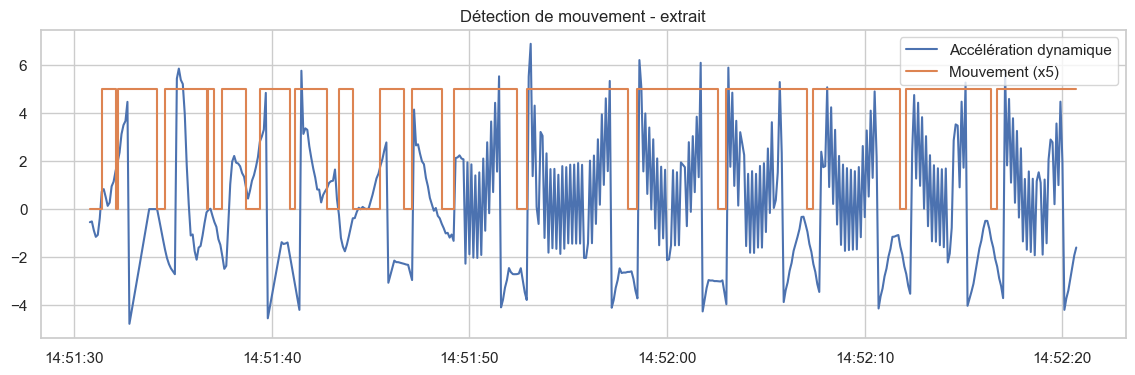

In [20]:
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']

# Norme de l'accélération
df_resampled['acc_norm'] = np.sqrt((df_resampled[acc_cols]**2).sum(axis=1))

# Gravité estimée (moyenne mobile large, 2 secondes = 20 points)
window_grav = 20
grav = df_resampled['acc_norm'].rolling(window=window_grav, center=True, min_periods=1).mean()
df_resampled['acc_dyn'] = df_resampled['acc_norm'] - grav

# Variance sur 1 seconde (10 points)
window_var = 10
df_resampled['acc_var'] = df_resampled['acc_dyn'].rolling(window=window_var, min_periods=1).var()

# Seuil à ajuster si besoin (0.5 est un bon début)
threshold = 0.5
df_resampled['is_moving'] = df_resampled['acc_var'] > threshold

# Visualisation d’un extrait (ex: 500 premières lignes)
plt.figure(figsize=(14,4))
plt.plot(df_resampled.index[:500], df_resampled['acc_dyn'][:500], label='Accélération dynamique')
plt.plot(df_resampled.index[:500], df_resampled['is_moving'][:500]*5, label='Mouvement (x5)', drawstyle='steps')
plt.legend()
plt.title("Détection de mouvement - extrait")
plt.show()

## Simulation des événements RFID

In [ ]:
events = []
df_resampled['prev_loc'] = df_resampled['location_id'].shift(1)

for i in range(1, len(df_resampled)):
    prev_loc = df_resampled['prev_loc'].iloc[i]
    curr_loc = df_resampled['location_id'].iloc[i]
    if curr_loc != prev_loc:
        # Sortie de l'ancienne zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'exit',
            'location_id': prev_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })
        # Entrée dans la nouvelle zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'enter',
            'location_id': curr_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })

rfid_events = pd.DataFrame(events)
print(f"Nombre d'événements RFID simulés : {len(rfid_events)}")
rfid_events.head(10)
# App

## Analyses complémentaires (durée de présence, transitions)

In [ ]:
# Durée de présence par zone (en secondes)
df_resampled['time_diff'] = df_resampled.index.to_series().diff().dt.total_seconds()
presence_zone = df_resampled.groupby('location_id')['time_diff'].sum().sort_values(ascending=False)
print("Temps passé par zone (secondes) :")
print(presence_zone)

# Matrice de transition entre zones
transitions = df_resampled[changement & (df_resampled['is_moving']==True)]
transitions['from'] = transitions['prev_location']
transitions['to'] = transitions['location_id']
mat_trans = pd.crosstab(transitions['from'], transitions['to'])
plt.figure(figsize=(8,6))
sns.heatmap(mat_trans, annot=True, cmap='Blues', fmt='d')
plt.title("Matrice des transitions entre zones (mouvement uniquement)")
plt.show()

## Visualisation finale : timeline des zones et mouvement

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Graphique des zones
ax1.plot(df_resampled.index, df_resampled['location_id'], drawstyle='steps-post', color='darkblue')
ax1.set_ylabel('Location ID')
ax1.set_title("Évolution des zones (location_id)")

# Graphique du mouvement + événements RFID
ax2.fill_between(df_resampled.index, 0, df_resampled['is_moving'].astype(int), alpha=0.3, label='Mouvement')
# Marquer les événements RFID (entrées uniquement)
entrees = rfid_df[rfid_df['event_type'] == 'enter']
ax2.scatter(entrees['timestamp'], [1.2]*len(entrees), marker='^', color='red', label='Entrée RFID', s=30)
ax2.set_ylabel('Mouvement (bool)')
ax2.set_xlabel('Temps')
ax2.legend()
plt.tight_layout()
plt.show()